In [1]:
import requests
import pandas as pd
import datetime
import json
import numpy as np
import matplotlib.pyplot as plt

In [44]:
data = {'Batch_KC8_id': 21, 'Batch_KC8_name': 'K2450', 'Batch_KC8_date': '2025-02-18T00:00:00', 'Batch_KC8_Technicien': 'FB', 'Batch_KC8_K_batch': 'AA', 'Batch_KC8_C_batch': 'AA', 'Batch_KC8_masse': 100.0, 'Batch_KC8_Temperature': 50.0, 'Batch_KC8_Agitation': 250, 'Batch_KC8_heure_debut': '2025-02-18T08:30:00', 'Batch_KC8_heure_fin': '2025-02-18T09:09:58', 'Batch_KC8_room_HR': 0.09, 'Batch_KC8_room_T': 25.0, 'Batch_KC8_Stock': 100.0, 'Batch_KC8_Analyses': 'None'}
response = requests.post(f'http://127.0.0.1:8000/KC8/update/{data['Batch_KC8_id']}', headers=headers, data=json.dumps(data))
response.content

b'"ok"'

In [197]:
response = requests.get(f'http://127.0.0.1:8000/analyses/')
o = pd.DataFrame(response.json())
# o.duplicated(subset='Analyse_name')
o.loc[o.Analyse_name == 'OGD2302-D']

,Analyses_id,Analyse_name,Analyse_subname,Analyse_details,Analyses_data
2,3,OGD2302-D,UV,"{'dillution': '1:10', 'centrifuge': False}","{'200': 0.0978437193021105, '210': 0.106003636..."
162,163,OGD2302-D,RAMAN,"{'group1_nbr': '191', 'group2_indiv': '30', 'g...","{'800': 0.0, '801': 0.0, '802': 0.0, '803': 0...."


In [210]:
status=dict()
response = requests.get(f'http://127.0.0.1:8000/matieres_premieres/name/{data["Batch_KC8_K_batch"]}')
status['get_K'] = response.status_code
updated_batch = response.json()
updated_batch['MP_quantite'] = int(updated_batch['MP_quantite'] - (39/(39+(8*12))*float(data['Batch_KC8_masse'])))
response = requests.post(f'http://127.0.0.1:8000/matieres_premieres/update/{updated_batch["MP_id"]}', headers=headers, data=json.dumps(updated_batch))
status['post_K'] = response.status_code


In [213]:
(39/(39+(8*12))*10)

2.8888888888888884

In [214]:
(8*12)/(39+(8*12))*10

7.111111111111112

In [212]:
updated_batch

{'MP_id': 201,
 'MP_nom': 'Carbone',
 'MP_codeCW': 'CW_001',
 'MP_ref_fournisseur': '000',
 'MP_date_reception': '2025-02-17T00:00:00',
 'MP_quantite': -35,
 'MP_unite': 'Kg',
 'MP_Analyses': 'None'}

In [209]:
url = 'http://127.0.0.1:8000/KC8/'
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'}
data={'Batch_KC8_name': 'K2506m', 'Batch_KC8_date': '2025-02-17T00:00:00', 'Batch_KC8_Technicien': 'FB', 'Batch_KC8_K_batch': '000', 'Batch_KC8_C_batch': '88888', 'Batch_KC8_masse': '5', 'Batch_KC8_Temperature': '50', 'Batch_KC8_Agitation': '250', 'Batch_KC8_heure_debut': '2025-02-17T23:39:00', 'Batch_KC8_heure_fin': None, 'Batch_KC8_room_HR': '0.09', 'Batch_KC8_room_T': '25', 'Batch_KC8_Stock': '5', 'Batch_KC8_Analyses': 'None'}
response = requests.post(url, headers=headers, data=json.dumps(data))
response.content


b'{"detail":"This batch already registered (error(mysql.connector.errors.IntegrityError) 1062 (23000): Duplicate entry \'K2506m\' for key \'batch_kc8.Batch_KC8_name\'\\n[SQL: INSERT INTO `Batch_KC8` (`Batch_KC8_name`, `Batch_KC8_date`, `Batch_KC8_Technicien`, `Batch_KC8_K_batch`, `Batch_KC8_C_batch`, `Batch_KC8_masse`, `Batch_KC8_Temperature`, `Batch_KC8_Agitation`, `Batch_KC8_heure_debut`, `Batch_KC8_heure_fin`, `Batch_KC8_room_HR`, `Batch_KC8_room_T`, `Batch_KC8_Stock`, `Batch_KC8_Analyses`) VALUES (%(Batch_KC8_name)s, %(Batch_KC8_date)s, %(Batch_KC8_Technicien)s, %(Batch_KC8_K_batch)s, %(Batch_KC8_C_batch)s, %(Batch_KC8_masse)s, %(Batch_KC8_Temperature)s, %(Batch_KC8_Agitation)s, %(Batch_KC8_heure_debut)s, %(Batch_KC8_heure_fin)s, %(Batch_KC8_room_HR)s, %(Batch_KC8_room_T)s, %(Batch_KC8_Stock)s, %(Batch_KC8_Analyses)s)]\\n[parameters: {\'Batch_KC8_name\': \'K2506m\', \'Batch_KC8_date\': datetime.datetime(2025, 2, 17, 0, 0), \'Batch_KC8_Technicien\': \'FB\', \'Batch_KC8_K_batch\': \'

In [62]:
response = requests.get('http://127.0.0.1:8000/Produit/')
Produits_all = pd.DataFrame(response.json())

Produits_all.loc[Produits_all.Batch_Produit_ref_CW.apply(lambda x : ('W' in x.split('-')[0]) & ('NC' not in x.split('-')[0]))]
Produits_all.loc[Produits_all.Batch_Produit_ref_CW.apply(lambda x : ('W' in x.split('-')[0]) & ('NC' in x.split('-')[0]))]
Produits_all.loc[Produits_all.Batch_Produit_ref_CW.apply(lambda x : ('Epo' in x.split('-')[0]) ),['Batch_Produit_ref_CW','Batch_Produit_date']]

,Batch_Produit_ref_CW,Batch_Produit_date
1,EpoR-2445,2024-11-07T00:00:00
4,EpoF-2313,2023-03-31T00:00:00
5,EpoR-2420,2024-05-14T00:00:00
6,EpoR-2344,2023-11-01T00:00:00
9,EpoF-2317,2023-04-24T00:00:00
11,EpoR-2438,2024-09-16T00:00:00
13,EpoR-2326,2023-07-02T00:00:00
14,EpoF-2305,2023-02-05T00:00:00
17,EpoR-2351,2023-12-24T00:00:00


In [ ]:
data = {'Batch_OGD_name': 'OGD2507', 'Batch_OGD_date': '2025-02-13T00:00:00', 'Batch_OGD_Technicien': 'FB', 'Batch_OGD_KC8_batch': 'K2460', 'Batch_OGD_KC8_masse': '50', 'Batch_OGD_THF_batch': 'B46EMVXIRIJjxaFd56y7', 'Batch_OGD_THF_Volume': '250', 'Batch_OGD_Temperature': '50', 'Batch_OGD_Agitation': '250', 'Batch_OGD_heure_debut': '2025-02-13T14:49:00', 'Batch_OGD_heure_fin': None, 'Batch_OGD_room_HR': '0.09', 'Batch_OGD_room_T': '25', 'Batch_OGD_Analyses': 'None'}


['K2453',
 'K2452',
 'K2451',
 'K2450',
 'K2448',
 'K2447',
 'K2446',
 'K2445',
 'K2444']

In [54]:
data = {'Batch_KC8_name': 'K2462', 'Batch_KC8_date': '2025-02-13T00:00:00', 'Batch_KC8_Technicien': 'FB', 'Batch_KC8_K_batch': 'UGAjlYgTOrGj1WPGGoDg', 'Batch_KC8_C_batch': '2dJMxNLnW02hrlK0EDDL', 'Batch_KC8_masse': '0.6', 'Batch_KC8_Temperature': '50', 'Batch_KC8_Agitation': '250', 'Batch_KC8_heure_debut': '2025-02-13T15:17:00', 'Batch_KC8_heure_fin': None, 'Batch_KC8_room_HR': '0.09', 'Batch_KC8_room_T': '25', 'Batch_KC8_Analyses': 'None'}
url = 'http://127.0.0.1:8000/KC8/'
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'}

response = requests.post(url, headers=headers, data=json.dumps(data))

response.content

b'{"detail":"This batch already registered (error(mysql.connector.errors.IntegrityError) 1062 (23000): Duplicate entry \'K2462\' for key \'batch_kc8.Batch_KC8_name\'\\n[SQL: INSERT INTO `Batch_KC8` (`Batch_KC8_name`, `Batch_KC8_date`, `Batch_KC8_Technicien`, `Batch_KC8_K_batch`, `Batch_KC8_C_batch`, `Batch_KC8_masse`, `Batch_KC8_Temperature`, `Batch_KC8_Agitation`, `Batch_KC8_heure_debut`, `Batch_KC8_heure_fin`, `Batch_KC8_room_HR`, `Batch_KC8_room_T`, `Batch_KC8_Analyses`) VALUES (%(Batch_KC8_name)s, %(Batch_KC8_date)s, %(Batch_KC8_Technicien)s, %(Batch_KC8_K_batch)s, %(Batch_KC8_C_batch)s, %(Batch_KC8_masse)s, %(Batch_KC8_Temperature)s, %(Batch_KC8_Agitation)s, %(Batch_KC8_heure_debut)s, %(Batch_KC8_heure_fin)s, %(Batch_KC8_room_HR)s, %(Batch_KC8_room_T)s, %(Batch_KC8_Analyses)s)]\\n[parameters: {\'Batch_KC8_name\': \'K2462\', \'Batch_KC8_date\': datetime.datetime(2025, 2, 13, 0, 0), \'Batch_KC8_Technicien\': \'FB\', \'Batch_KC8_K_batch\': \'UGAjlYgTOrGj1WPGGoDg\', \'Batch_KC8_C_batc

In [ ]:
data={"Batch_KC8_name": "K2460", "Batch_KC8_date": "2025-02-13T00:00:00", "Batch_KC8_Technicien": "FB", "Batch_KC8_K_batch": "UGAjlYgTOrGj1WPGGoDg", "Batch_KC8_C_batch": "2dJMxNLnW02hrlK0EDDL", "Batch_KC8_masse": 0.6, "Batch_KC8_Temperature": 50.0, "Batch_KC8_Agitation": 250, "Batch_KC8_heure_debut": "2025-02-13T14:40:00", "Batch_KC8_heure_fin": null, "Batch_KC8_room_HR": 0.09, "Batch_KC8_room_T": 25.0, "Batch_KC8_Analyses": "None"}
url = 'http://127.0.0.1:8000/KC8/'
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'}

response = requests.post(url, headers=headers, data=json.dumps(data))


In [34]:
data ={'Envoi_date_commande': '2025-02-13T00:00:00', 'Envoi_client_name': 'CLIENT TEST', 'Envoi_produit_name': 'CLIENT TEST', 'Envoi_produit_batch': None, 'Envoi_produit_Qte': '50', 'Envoi_produit_emballage': '', 'Envoi_date_prevu': '2025-01-30T00:00:00', 'Envoi_date_effective': None, 'Envoi_code_coli': None, 'Envoi_retour_client': None}
response = requests.post(f'http://127.0.0.1:8000/Envoi/',data=json.dumps(data))
response.content


b'{"detail":"This batch already registered (error(mysql.connector.errors.DataError) 1406 (22001): Data too long for column \'Envoi_produit_name\' at row 1\\n[SQL: INSERT INTO `Envois` (`Envoi_date_commande`, `Envoi_client_name`, `Envoi_produit_name`, `Envoi_produit_batch`, `Envoi_produit_Qte`, `Envoi_produit_emballage`, `Envoi_date_prevu`, `Envoi_date_effective`, `Envoi_code_coli`, `Envoi_delivered`, `Envoi_retour_client`) VALUES (%(Envoi_date_commande)s, %(Envoi_client_name)s, %(Envoi_produit_name)s, %(Envoi_produit_batch)s, %(Envoi_produit_Qte)s, %(Envoi_produit_emballage)s, %(Envoi_date_prevu)s, %(Envoi_date_effective)s, %(Envoi_code_coli)s, %(Envoi_delivered)s, %(Envoi_retour_client)s)]\\n[parameters: {\'Envoi_date_commande\': datetime.datetime(2025, 2, 13, 0, 0), \'Envoi_client_name\': \'CLIENT TEST\', \'Envoi_produit_name\': \'CLIENT TEST\', \'Envoi_produit_batch\': None, \'Envoi_produit_Qte\': 50.0, \'Envoi_produit_emballage\': \'\', \'Envoi_date_prevu\': datetime.datetime(2025,

<Axes: title={'center': 'Stocks produit sur etagere'}, ylabel='Quantité disponible (Kg)'>

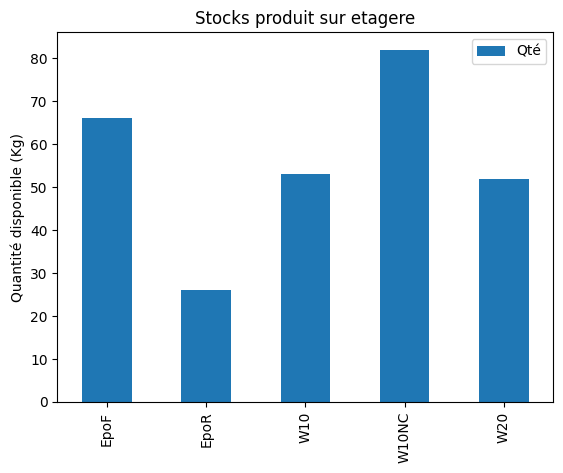

In [ ]:
response = requests.get(f'http://127.0.0.1:8000/Produit/')
array = np.array([(a['Batch_Produit_ref_CW'],a['Batch_Produit_OGD_Qte']) for a in response.json()])
df = pd.DataFrame(array, columns=['produit','Qté'])
df['Categorie'] = df.produit.apply(lambda x :x.split("-")[0])
df['Qté'] = df['Qté'].astype(float)
df.groupby('Categorie').sum().plot.bar(title = 'Stocks produit sur etagere',ylabel='Quantité disponible (Kg)',xlabel='')

# import plotly.express as px

# fig = px.bar(df,x='Categorie',y='Qté')
# fig.show()

In [5]:
response.json()

[]

In [4]:
from Front.utils import *

response = requests.get(f'http://127.0.0.1:8000/matieres_premieres/')
get_matieres_premieres(response)

('pimiIFYLS9rqsvNYnURW', 'gx9NZ0nrGriwB0H1qcL6', 'A1gEoZYktn6UQ5PnxL15')

In [ ]:
m = requests.get(f'http://127.0.0.1:8000/matieres_premieres/')
n = 


,MP_id,MP_nom,MP_codeCW,MP_ref_fournisseur,MP_date_reception,MP_quantite,MP_unite,MP_Analyses
0,1,Potassium,CW_003,9WoHuuWW4Jp1Sv74lYGN,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
1,2,Potassium,CW_003,I2erMP4GUsmJ918tsqrs,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
2,3,Potassium,CW_003,tCbiOkhVjj36ekQk5Zbo,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
3,4,Potassium,CW_003,FzglKkucRX0MkQlZMhIv,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
4,5,Potassium,CW_003,r6DCNmLPuVvnRNvl9dgX,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
...,...,...,...,...,...,...,...,...
205,206,Carbone,CW_001,s0H75wpxf3C9OMTMXw3H,2023-01-01T00:00:00,0.0,Kg,None
206,207,Carbone,CW_001,s0H75wpxf3C9OMTMXw3H,2023-01-01T00:00:00,0.0,Kg,None
207,208,Carbone,CW_001,AIG772GD9,2025-02-04T00:00:00,20.0,Kg,None
208,209,Potassium,CW_002,00000QQQQQ,2025-02-04T00:00:00,10.0,Kg,None


In [6]:
MP

,MP_id,MP_nom,MP_codeCW,MP_ref_fournisseur,MP_date_reception,MP_quantite,MP_unite,MP_Analyses
0,1,Potassium,CW_003,9WoHuuWW4Jp1Sv74lYGN,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
1,2,Potassium,CW_003,I2erMP4GUsmJ918tsqrs,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
2,3,Potassium,CW_003,tCbiOkhVjj36ekQk5Zbo,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
3,4,Potassium,CW_003,FzglKkucRX0MkQlZMhIv,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
4,5,Potassium,CW_003,r6DCNmLPuVvnRNvl9dgX,2023-01-01T00:00:00,0.0,kg,codes_analyses_separated_by_commas
...,...,...,...,...,...,...,...,...
203,204,Potassium,CW_002,9WoHuuWW4Jp1Sv74lYGN,2023-01-01T00:00:00,0.0,L,None
204,205,Carbone,CW_001,s0H75wpxf3C9OMTMXw3H,2023-01-01T00:00:00,0.0,Kg,None
205,206,Carbone,CW_001,s0H75wpxf3C9OMTMXw3H,2023-01-01T00:00:00,0.0,Kg,None
206,207,Carbone,CW_001,s0H75wpxf3C9OMTMXw3H,2023-01-01T00:00:00,0.0,Kg,None


In [7]:
MP.loc[MP.MP_nom=='Carbone',['MP_ref_fournisseur','MP_quantite','MP_unite']]

,MP_ref_fournisseur,MP_quantite,MP_unite
201,4qR8YaqQrEo2TJXDnyw7,0.0,L
204,s0H75wpxf3C9OMTMXw3H,0.0,Kg
205,s0H75wpxf3C9OMTMXw3H,0.0,Kg
206,s0H75wpxf3C9OMTMXw3H,0.0,Kg
207,AIG772GD9,20.0,Kg


In [13]:
Envois_all=pd.DataFrame(response.json())
Envois_all.loc[Envois_all.Envoi_produit_batch.isnull(),['Envoi_produit_name','Envoi_produit_Qte']].values

array([], shape=(0, 2), dtype=object)

In [15]:
Envois_all.isnull()

,Envoi_id,Envoi_date_commande,Envoi_client_name,Envoi_produit_name,Envoi_produit_batch,Envoi_produit_Qte,Envoi_produit_emballage,Envoi_date_prevu,Envoi_date_effective,Envoi_code_coli,Envoi_retour_client
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False


In [7]:
response = requests.get('http://127.0.0.1:8000/KC8/name/K2454')
response.json()


{'Batch_KC8_id': 1,
 'Batch_KC8_name': 'K2454',
 'Batch_KC8_date': '2023-07-26T00:00:00',
 'Batch_KC8_Technicien': 'WL',
 'Batch_KC8_K_batch': 'icjb7a3BpUqaAjdfTFwO',
 'Batch_KC8_C_batch': 'CGjZ1rAL5Gr8g47JpraI',
 'Batch_KC8_masse': 200,
 'Batch_KC8_Temperature': 60.0,
 'Batch_KC8_Agitation': 250,
 'Batch_KC8_heure_debut': '2023-07-26T12:00:00',
 'Batch_KC8_heure_fin': '2023-07-26T14:00:00',
 'Batch_KC8_room_HR': 28.0,
 'Batch_KC8_room_T': 0.3,
 'Batch_KC8_Analyses': 'codes_analyses_separated_by_commas'}

In [9]:
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'}

data = {"Batch_KC8_id": 199, "Batch_KC8_name": "K2403", "Batch_KC8_date": "2025-01-03T00:00:00", "Batch_KC8_Technicien": "LC", "Batch_KC8_K_batch": "XM1DlrekybkXzl4ZKXDC", "Batch_KC8_C_batch": "amqaNvqew67D345ZESZ1", "Batch_KC8_masse": 150, "Batch_KC8_Temperature": 60.0, "Batch_KC8_Agitation": 250, "Batch_KC8_heure_debut": "2025-01-03T12:00:00", "Batch_KC8_heure_fin": "2025-01-03T15:00:00", "Batch_KC8_room_HR": 20.0, "Batch_KC8_room_T": 0.2, "Batch_KC8_Analyses": "codes_analyses_separated_by_commas"}

response = requests.post(f'http://127.0.0.1:8000/KC8/update/199', headers=headers, data=json.dumps(data))


In [11]:
response.content

b'Internal Server Error'

In [ ]:
analyses_UV = pd.DataFrame(response.json()).sort_values('Batch_OGD_id', ascending=False)


In [36]:
UV_OGD[['Analyse_UV_name','conc']]

,Analyses_UV_id,Analyse_UV_name,Analyse_UV_subname,Analyse_UV_details,Analyses_UV_data,conc
0,1,OGD2415D,UV,"{'dillution': '1:10', 'centrifuge': False}","{'200': 0.07011012641841068, '210': 0.08197060...",0.007011


,Batch_OGD_name,Batch_OGD_date,Batch_OGD_KC8_masse
0,OGD2415D,2024-01-26T00:00:00,20.0
1,OGD2307D,2023-08-05T00:00:00,20.0
2,OGD2353D,2023-09-14T00:00:00,20.0
3,OGD2323B,2023-10-11T00:00:00,20.0
4,OGD2334C,2023-06-03T00:00:00,20.0
...,...,...,...
161,OGD2311A,2024-04-10T00:00:00,20.0
162,OGD2437D,2023-06-14T00:00:00,20.0
163,OGD2446A,2024-05-08T00:00:00,20.0
164,OGD2504A,2025-01-24T00:00:00,50.0


In [40]:
df

,Batch_OGD_name,Batch_OGD_date,Batch_OGD_KC8_masse,Analyse_UV_name,conc
0,OGD2415D,2024-01-26T00:00:00,20.0,OGD2415D,0.007011


## test graphs plotly in front

In [45]:
import plotly
import plotly.express as px


# get data from bdd
    # analyses UV
url = 'http://127.0.0.1:8000/'
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'}
response = requests.get(url+f'analyses_UV',headers=headers)
UV_OGD = pd.DataFrame(response.json())
UV_OGD['conc'] = UV_OGD[['Analyse_UV_name','Analyse_UV_details','Analyses_UV_data']].apply(lambda x: x[2]['200'] / float(x[1]['dillution'].split(':')[1]), axis=1)
    # info batch date
response = requests.get(url+f'OGD',headers=headers)
batch_OGD = pd.DataFrame(response.json())

# create new df
df=pd.merge(batch_OGD[['Batch_OGD_name','Batch_OGD_date','Batch_OGD_KC8_masse']],
         UV_OGD[['Analyse_UV_name','conc']],
         left_on='Batch_OGD_name',
         right_on='Analyse_UV_name',
         how='inner')
    # format date
df['Batch_OGD_date'] = pd.to_datetime(df['Batch_OGD_date'])
df['week'] = df.Batch_OGD_date.apply(lambda x : x.week) #df.Batch_name.apply(lambda x : pd.to_datetime(int(x[2:4]),unit='W').week)  # df['date'].dt.week # 
df['month'] = df.Batch_OGD_date.apply(lambda x : x.month) #Batch_name.apply(lambda x : pd.to_datetime(int(x[2:4]),unit='W').month) # df['date'].dt.month # 
df['year'] = df.Batch_OGD_date.apply(lambda x : x.year)
df.Batch_OGD_KC8_masse = df.Batch_OGD_KC8_masse.apply(lambda x : int(round(x)))
    # Pivot Table
table = pd.pivot_table(df, 
                index=[ 'month', 'week'], 
                values=['Batch_OGD_name', 'conc'], 
                aggfunc={'Batch_OGD_name': 'count', 'conc': ['sum', 'mean']})
    # create graph
fig = px.box(df, x='Batch_OGD_date', y="conc", points="all")
graphJSON = json.dumps(fig, cls=plotly.utils.PlotlyJSONEncoder)

/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_51658/1132335657.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  UV_OGD['conc'] = UV_OGD[['Analyse_UV_name','Analyse_UV_details','Analyses_UV_data']].apply(lambda x: x[2]['200'] / float(x[1]['dillution'].split(':')[1]), axis=1)


In [2]:
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'}

# TEST CALCULATE MATERIALS

In [39]:
response = requests.get(f'http://127.0.0.1:8000/matieres_premieres/')
pd.DataFrame(response.json())[::-1]

,MP_id,MP_nom,MP_codeCW,MP_ref_fournisseur,MP_date_reception,MP_quantite,MP_unite,MP_Analyses
21,22,Potassium,CW_002,AA,2025-02-18T00:00:00,200.0,Kg,None
20,21,Carbone,CW_001,AA,2025-02-18T00:00:00,71.0,Kg,None
19,20,Carbone,CW_002,Xc7jd,2025-01-07T00:00:00,0.0,kg,codes_analyses_separated_by_commas
18,19,Carbone,CW_002,zqQXv,2024-12-11T00:00:00,0.0,kg,codes_analyses_separated_by_commas
17,18,Carbone,CW_002,n9fxq,2024-08-13T00:00:00,0.0,kg,codes_analyses_separated_by_commas
16,17,Carbone,CW_002,smvS3,2024-07-23T00:00:00,0.0,kg,codes_analyses_separated_by_commas
15,16,THF,CW_001,GNBWA,2024-05-29T00:00:00,0.0,L,codes_analyses_separated_by_commas
14,15,Potassium,CW_003,7duxt,2024-05-14T00:00:00,0.0,kg,codes_analyses_separated_by_commas
13,14,Carbone,CW_002,g6GHU,2024-03-09T00:00:00,0.0,kg,codes_analyses_separated_by_commas
12,13,Carbone,CW_002,qaUIs,2024-01-17T00:00:00,0.0,kg,codes_analyses_separated_by_commas


In [25]:
data={'Batch_KC8_name': 'K2450', 'Batch_KC8_date': '2025-02-18T00:00:00', 'Batch_KC8_Technicien': 'FB', 'Batch_KC8_K_batch': 'AA', 'Batch_KC8_C_batch': 'AA', 'Batch_KC8_masse': '100', 'Batch_KC8_Temperature': '50', 'Batch_KC8_Agitation': '250', 'Batch_KC8_heure_debut': '2025-02-18T08:30:00', 'Batch_KC8_heure_fin': None, 'Batch_KC8_room_HR': '0.09', 'Batch_KC8_room_T': '25', 'Batch_KC8_Stock': '100', 'Batch_KC8_Analyses': 'None'}
print(data['Batch_KC8_K_batch'])

AA


In [40]:
response = requests.get(f'http://127.0.0.1:8000/matieres_premieres/name/AA')
updated_batch = response.json()
updated_batch

{'MP_id': 21,
 'MP_nom': 'Carbone',
 'MP_codeCW': 'CW_001',
 'MP_ref_fournisseur': 'AA',
 'MP_date_reception': '2025-02-18T00:00:00',
 'MP_quantite': 71.0,
 'MP_unite': 'Kg',
 'MP_Analyses': 'None'}

In [27]:
print(data['Batch_KC8_masse'])
print(39/(39+(8*12))*float(data['Batch_KC8_masse']))

100
28.888888888888886


In [34]:
updated_batch['MP_quantite'] = updated_batch['MP_quantite'] - (39/(39+(8*12))*float(data['Batch_KC8_masse']))
updated_batch['MP_quantite']

71.00001111111112

In [35]:
print(data["Batch_KC8_K_batch"])
print(updated_batch["MP_id"])

AA
21


In [36]:
response = requests.post(f'http://127.0.0.1:8000/matieres_premieres/update/{updated_batch["MP_id"]}', headers=headers, data=json.dumps(updated_batch))
response.content

b'"ok"'

In [37]:
response = requests.get(f'http://127.0.0.1:8000/matieres_premieres/id/{updated_batch["MP_id"]}')
response.json()

{'MP_id': 21,
 'MP_nom': 'Carbone',
 'MP_codeCW': 'CW_001',
 'MP_ref_fournisseur': 'AA',
 'MP_date_reception': '2025-02-18T00:00:00',
 'MP_quantite': 71.0,
 'MP_unite': 'Kg',
 'MP_Analyses': 'None'}

In [ ]:

status=dict()
# update stock of K 
response = requests.get(f'http://127.0.0.1:8000/matieres_premieres/name/{data["Batch_KC8_K_batch"]}')
status['get_K'] = response.status_code
updated_batch = response.json()
updated_batch['MP_quantite'] = int(updated_batch['MP_quantite'] - (39/(39+(8*12))*float(data['Batch_KC8_masse'])))
response = requests.post(f'http://127.0.0.1:8000/matieres_premieres/update/{updated_batch["MP_id"]}', headers=headers, data=json.dumps(updated_batch))
status['post_K'] = response.status_code

# update stock of C
response = requests.get(f'http://127.0.0.1:8000/matieres_premieres/name/{data["Batch_KC8_C_batch"]}')
updated_batch = response.json()
status['get_C'] = response.status_code
updated_batch['MP_quantite'] = updated_batch['MP_quantite'] - ((8*12)/(39+(8*12))*float(data['Batch_KC8_masse']))
response = requests.post(f'http://127.0.0.1:8000/matieres_premieres/update/{updated_batch["MP_id"]}', headers=headers, data=json.dumps(updated_batch))
status['post_C'] = response.status_code
